# Image Dehazing using AOD-Net with Residual Learning and Skip Connections

This notebook turns the core logic of the repository `walsvid/AOD-Net-PyTorch` into a clean, step-by-step academic workflow.

## Why image dehazing matters

Haze reduces contrast, washes out colors, and hides scene details because atmospheric particles scatter light before it reaches the camera. In practice, dehazing is useful for autonomous driving, surveillance, remote sensing, and general image enhancement.

## Why AOD-Net

AOD-Net is a compact convolutional neural network that learns a direct mapping from a hazy image to a cleaner image. Instead of relying on complicated hand-crafted priors, it learns the dehazing transformation from paired examples.

## What this notebook demonstrates

- A lightweight recreation of the original AOD-Net architecture.
- A residual-learning variant that predicts haze residue and subtracts it from the input.
- A skip-connection variant that adds the input image back to help preserve details.
- Training, evaluation, PSNR analysis, and visual comparison in one place.

The notebook is designed to run section by section and is suitable for classroom explanation or project presentation.


## Repository Mapping

This notebook follows the original GitHub repository closely while simplifying it for presentation:

- `model.py` -> baseline AOD-Net feature extractor and forward equation.
- `train.py` -> PyTorch training loop with MSE loss, Adam optimizer, and gradient clipping.
- `demo.py` -> single-image inference helper.
- `data.py` -> paired `(clean, hazy)` training setup.

Because an external dataset may not be available during a presentation, the notebook can generate synthetic clean scenes and then simulate haze using the atmospheric scattering model.


## Imports and Setup

The notebook uses PyTorch, torchvision, NumPy, Pillow, and matplotlib. If you are running this in a fresh environment, install them first with a command such as:

```bash
pip install torch torchvision matplotlib pillow numpy
```

The next cell sets the random seed, image size, training hyperparameters, and output folders.


In [1]:
# Core notebook imports and reproducibility helpers.
from pathlib import Path
import math
import os
import random
import shutil
import subprocess
import sys

# Deep learning imports.
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

# Keep all temporary notebook files inside the project folder.
PROJECT_ROOT = Path.cwd()
MPLCONFIG_DIR = PROJECT_ROOT / '.mplconfig'
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR))

# Plotting and image utilities.
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

# Centralized experiment settings so they are easy to change in one place.
SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 0.1
MAX_KAGGLE_PAIRS = 600

LOCAL_IMAGE_DIR = PROJECT_ROOT / 'data' / 'clean_images'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT = PROJECT_ROOT / 'data'
DATA_ROOT.mkdir(parents=True, exist_ok=True)
KAGGLE_DOWNLOAD_DIR = DATA_ROOT / 'downloads'
KAGGLE_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_EXTRACT_DIR = DATA_ROOT / 'reside_6k'
ORGANIZED_HAZY_DIR = DATA_ROOT / 'hazy'
ORGANIZED_CLEAN_DIR = DATA_ROOT / 'clean'

def seed_everything(seed=42):
    """Set seeds so experiments are easy to reproduce."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## Utility Functions

These helpers keep the notebook readable:

- convert tensors into displayable images,
- show multiple images side by side,
- count trainable parameters for model comparison.


In [2]:
# Helper functions for image conversion and visualization.
# These keep the later training and plotting cells short and readable.
to_tensor = transforms.ToTensor()
resize_to_tensor = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
])

def tensor_to_numpy(image_tensor):
    """Convert a PyTorch tensor in CHW format to a NumPy image in HWC format."""
    image_tensor = image_tensor.detach().cpu().clamp(0, 1)
    return image_tensor.permute(1, 2, 0).numpy()

def show_image_grid(images, titles=None, figsize=(16, 4), suptitle=None):
    """Display a list of images in a single row for easy comparison."""
    # Create one subplot per image so comparisons are easy to explain in class.
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]

    for idx, (ax, image) in enumerate(zip(axes, images)):
        ax.imshow(tensor_to_numpy(image) if isinstance(image, torch.Tensor) else image)
        ax.axis('off')
        if titles is not None:
            ax.set_title(titles[idx], fontsize=11)

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

def count_parameters(model):
    """Count trainable parameters to confirm the models stay lightweight."""
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


## Dataset Section

The original repository expects paired clean and hazy images from disk. For a self-contained project notebook, we support two options:

1. Load clean images from `data/clean_images` if you already have them.
2. Generate synthetic clean scenes and then add haze mathematically.

The haze simulation follows the atmospheric scattering idea:

$$I(x) = J(x)t(x) + A(1 - t(x))$$

where `J(x)` is the clean image, `I(x)` is the hazy image, `A` is atmospheric light, and `t(x)` is the transmission map.


## Optional Kaggle Dataset Setup

This notebook can automatically try to download the `reside-6k` dataset from Kaggle.

### How to get your Kaggle API key

1. Open your Kaggle account page: https://www.kaggle.com/settings/account
2. Scroll to the **API** section.
3. Click **Create New API Token**.
4. Kaggle will download a file called `kaggle.json`.

### Two supported authentication methods

**Method 1: Environment variables**

You can set:

```python
import os
os.environ["KAGGLE_USERNAME"] = "your_username"
os.environ["KAGGLE_KEY"] = "your_api_key"
```

**Method 2: `kaggle.json` file**

You can place or upload `kaggle.json` and then point the notebook to it.  
The notebook will copy it to the standard Kaggle location and set permissions if needed.

### Important note

This setup is optional. If Kaggle download fails for any reason, the notebook will print a clear message and automatically switch back to synthetic haze generation.


In [3]:
# Kaggle setup helpers.
# These functions make dataset download optional, safe, and easy to follow.
KAGGLE_JSON_SOURCE = None
KAGGLE_DATASET_SLUG = 'kmljts/reside-6k'
USE_KAGGLE_DATASET = True
DOWNLOADED_DATASET_READY = False

def ensure_package_installed(package_name):
    """Install a package from inside the notebook only if it is missing."""
    try:
        __import__(package_name)
        return True
    except ImportError:
        print(f'Installing missing package: {package_name}')
        try:
            completed = subprocess.run(
                [sys.executable, '-m', 'pip', 'install', package_name],
                check=True,
                capture_output=True,
                text=True,
            )
            if completed.stdout.strip():
                print(completed.stdout.strip())
            return True
        except Exception as exc:
            print(f'Could not install {package_name}.')
            print('Reason:', exc)
            print('The notebook will continue and use synthetic data if Kaggle setup is unavailable.')
            return False

def configure_kaggle_credentials(kaggle_json_source=None):
    """Set up Kaggle credentials from environment variables or a kaggle.json file."""
    username = os.environ.get('KAGGLE_USERNAME')
    api_key = os.environ.get('KAGGLE_KEY')

    if username and api_key:
        print('Kaggle credentials found in environment variables.')
        return True

    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_target = kaggle_dir / 'kaggle.json'

    if kaggle_json_source is not None:
        kaggle_json_source = Path(kaggle_json_source)
        if kaggle_json_source.exists():
            shutil.copy2(kaggle_json_source, kaggle_json_target)
            try:
                os.chmod(kaggle_json_target, 0o600)
            except Exception:
                pass
            print(f'Copied kaggle.json to {kaggle_json_target}')
            return True

    if kaggle_json_target.exists():
        print(f'Using existing kaggle.json from {kaggle_json_target}')
        return True

    print('Kaggle credentials were not found. The notebook will use the synthetic fallback dataset.')
    return False

def run_command(command, working_directory=None):
    """Run a shell command and return whether it succeeded."""
    try:
        completed = subprocess.run(
            command,
            cwd=working_directory,
            check=True,
            capture_output=True,
            text=True,
        )
        if completed.stdout.strip():
            print(completed.stdout.strip())
        return True
    except subprocess.CalledProcessError as exc:
        if exc.stdout:
            print(exc.stdout.strip())
        if exc.stderr:
            print(exc.stderr.strip())
        return False

def extract_zip_file(zip_path, extract_to):
    """Extract a Kaggle zip file into the local data directory."""
    import zipfile

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

def list_image_files(folder_path):
    """Return all image files inside a folder tree."""
    folder_path = Path(folder_path)
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp'}
    return [path for path in folder_path.rglob('*') if path.suffix.lower() in image_extensions]

def find_candidate_image_dirs(root_dir, keywords):
    """Find subfolders whose names suggest they contain hazy or clean images."""
    root_dir = Path(root_dir)
    candidates = []
    for folder in root_dir.rglob('*'):
        if folder.is_dir():
            folder_name = folder.name.lower()
            if any(keyword in folder_name for keyword in keywords):
                image_count = len(list_image_files(folder))
                if image_count > 0:
                    candidates.append((folder, image_count))
    candidates.sort(key=lambda item: item[1], reverse=True)
    return [folder for folder, _ in candidates]

def copy_images_into_standard_dir(source_dirs, target_dir):
    """Copy image files from one or more source folders into a standard folder."""
    if not isinstance(source_dirs, (list, tuple)):
        source_dirs = [source_dirs]
    source_dirs = [Path(source_dir) for source_dir in source_dirs]
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    if any(target_dir.iterdir()):
        print(f'Skipping copy because {target_dir} already contains files.')
        return

    for source_dir in source_dirs:
        for image_path in list_image_files(source_dir):
            shutil.copy2(image_path, target_dir / image_path.name)

def download_and_prepare_kaggle_dataset(dataset_slug=KAGGLE_DATASET_SLUG, kaggle_json_source=KAGGLE_JSON_SOURCE):
    """Download the Kaggle dataset, extract it, and map it into data/hazy and data/clean."""
    global DOWNLOADED_DATASET_READY

    if not USE_KAGGLE_DATASET:
        print('Kaggle dataset setup is disabled. Synthetic data will be used instead.')
        DOWNLOADED_DATASET_READY = False
        return

    if not ensure_package_installed('kaggle'):
        print('Kaggle API could not be installed. Falling back to synthetic data.')
        DOWNLOADED_DATASET_READY = False
        return

    if not configure_kaggle_credentials(kaggle_json_source=kaggle_json_source):
        DOWNLOADED_DATASET_READY = False
        return

    zip_path = KAGGLE_DOWNLOAD_DIR / 'reside-6k.zip'
    KAGGLE_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    KAGGLE_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    ORGANIZED_HAZY_DIR.mkdir(parents=True, exist_ok=True)
    ORGANIZED_CLEAN_DIR.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print('Downloading dataset from Kaggle...')
        command = [
            'kaggle', 'datasets', 'download',
            '-d', dataset_slug,
            '-p', str(KAGGLE_DOWNLOAD_DIR),
        ]
        if not run_command(command):
            print('Kaggle download failed. Switching to synthetic data.')
            DOWNLOADED_DATASET_READY = False
            return
    else:
        print(f'Using existing download: {zip_path}')

    try:
        print('Extracting dataset archive...')
        extract_zip_file(zip_path, KAGGLE_EXTRACT_DIR)
    except Exception as exc:
        print(f'Failed to extract Kaggle dataset: {exc}')
        print('Switching to synthetic data.')
        DOWNLOADED_DATASET_READY = False
        return

    hazy_candidates = find_candidate_image_dirs(KAGGLE_EXTRACT_DIR, keywords=['hazy', 'haze'])
    clean_candidates = find_candidate_image_dirs(KAGGLE_EXTRACT_DIR, keywords=['clean', 'clear', 'gt', 'original'])

    if not hazy_candidates or not clean_candidates:
        print('Could not map the dataset structure automatically.')
        print('Switching to synthetic data.')
        DOWNLOADED_DATASET_READY = False
        return

    print('Mapped hazy folders:')
    for folder in hazy_candidates:
        print(f' - {folder}')
    print('Mapped clean folders:')
    for folder in clean_candidates:
        print(f' - {folder}')

    copy_images_into_standard_dir(hazy_candidates, ORGANIZED_HAZY_DIR)
    copy_images_into_standard_dir(clean_candidates, ORGANIZED_CLEAN_DIR)

    hazy_count = len(list_image_files(ORGANIZED_HAZY_DIR))
    clean_count = len(list_image_files(ORGANIZED_CLEAN_DIR))
    DOWNLOADED_DATASET_READY = hazy_count > 0 and clean_count > 0

    if DOWNLOADED_DATASET_READY:
        print(f'Kaggle dataset is ready. Hazy images: {hazy_count} | Clean images: {clean_count}')
    else:
        print('Dataset folders are empty after preparation. Switching to synthetic data.')

# Method 1 example:
# os.environ['KAGGLE_USERNAME'] = 'your_username'
# os.environ['KAGGLE_KEY'] = 'your_api_key'
#
# Method 2 example:
# KAGGLE_JSON_SOURCE = PROJECT_ROOT / 'kaggle.json'
download_and_prepare_kaggle_dataset()


Using existing kaggle.json from C:\Users\ranja\.kaggle\kaggle.json
Using existing download: D:\JetAcker_RoadSim\NNDL_Project\data\downloads\reside-6k.zip
Extracting dataset archive...


Mapped hazy folders:
 - D:\JetAcker_RoadSim\NNDL_Project\data\reside_6k\RESIDE-6K\train\hazy
 - D:\JetAcker_RoadSim\NNDL_Project\data\reside_6k\RESIDE-6K\test\hazy
Mapped clean folders:
 - D:\JetAcker_RoadSim\NNDL_Project\data\reside_6k\RESIDE-6K\train\GT
 - D:\JetAcker_RoadSim\NNDL_Project\data\reside_6k\RESIDE-6K\test\GT


Kaggle dataset is ready. Hazy images: 7000 | Clean images: 7000


Using Kaggle dataset from data/hazy and data/clean.
Using a subset of 600 Kaggle pairs for a faster notebook run.
Train samples: 480 | Validation samples: 120


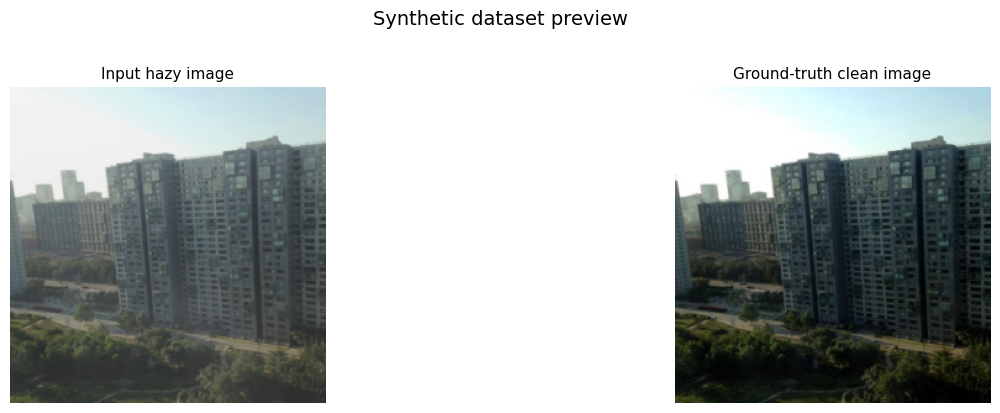

In [4]:
# This section either loads local clean images or creates synthetic outdoor scenes.
# The goal is to make the notebook runnable even when no external dataset is available.
def generate_clean_scene(size=IMAGE_SIZE, seed=0):
    """Create a simple synthetic outdoor image so the notebook works without an external dataset."""
    rng = random.Random(seed)
    width, height = size
    canvas = Image.new('RGB', size)
    draw = ImageDraw.Draw(canvas)
    pixels = canvas.load()

    horizon = int(height * rng.uniform(0.52, 0.64))
    sky_top = np.array([85, 160, 245], dtype=np.float32)
    sky_bottom = np.array([235, 245, 255], dtype=np.float32)
    land_top = np.array([85, 155, 90], dtype=np.float32)
    land_bottom = np.array([28, 58, 38], dtype=np.float32)

    # Paint a sky-to-ground gradient so haze effects become easy to see.
    for y in range(height):
        if y < horizon:
            t = y / max(horizon - 1, 1)
            color = (1 - t) * sky_top + t * sky_bottom
        else:
            t = (y - horizon) / max(height - horizon - 1, 1)
            color = (1 - t) * land_top + t * land_bottom
        color = tuple(np.clip(color, 0, 255).astype(np.uint8))
        for x in range(width):
            pixels[x, y] = color

    # Add a bright sun.
    sun_radius = rng.randint(14, 28)
    sun_x = rng.randint(30, width - 30)
    sun_y = rng.randint(25, max(35, horizon - 25))
    draw.ellipse([sun_x - sun_radius, sun_y - sun_radius, sun_x + sun_radius, sun_y + sun_radius], fill=(255, 241, 175))

    # Add a few clouds.
    for _ in range(rng.randint(2, 4)):
        cloud_x = rng.randint(15, width - 70)
        cloud_y = rng.randint(15, max(25, horizon - 45))
        for shift in [0, 18, 36]:
            draw.ellipse([cloud_x + shift, cloud_y, cloud_x + shift + 34, cloud_y + 20], fill=(252, 252, 252))

    # Add mountain-like shapes in the distance.
    for layer in range(3):
        base_y = int(horizon - (2 - layer) * height * 0.08)
        peak_y = base_y - rng.randint(35, 85)
        points = [(0, base_y)]
        current_x = 0
        while current_x < width:
            current_x = min(width, current_x + rng.randint(22, 48))
            points.append((current_x, rng.randint(peak_y, base_y)))
        points.extend([(width, height), (0, height)])
        base_color = np.array([75, 105, 125], dtype=np.float32) + layer * np.array([24, 20, 14], dtype=np.float32)
        draw.polygon(points, fill=tuple(np.clip(base_color, 0, 255).astype(np.uint8)))

    # Add a road to create strong geometric edges that are useful for visual comparison.
    road_top_y = int(horizon + height * 0.07)
    draw.polygon([
        (int(width * 0.42), road_top_y),
        (int(width * 0.58), road_top_y),
        (int(width * 0.82), height),
        (int(width * 0.18), height),
    ], fill=(68, 68, 78))
    for lane_y in range(road_top_y + 8, height, 22):
        lane_width = max(3, int((lane_y - road_top_y) / height * 8) + 3)
        draw.rectangle([
            width // 2 - lane_width,
            lane_y,
            width // 2 + lane_width,
            min(lane_y + 10, height),
        ], fill=(255, 245, 175))

    # Add buildings near the horizon.
    for _ in range(rng.randint(4, 7)):
        x0 = rng.randint(0, width - 26)
        x1 = x0 + rng.randint(14, 30)
        y1 = rng.randint(horizon + 8, int(height * 0.82))
        y0 = y1 - rng.randint(26, 70)
        building_color = tuple(rng.randint(70, 205) for _ in range(3))
        draw.rectangle([x0, y0, x1, y1], fill=building_color)
        for window_y in range(y0 + 5, y1 - 4, 10):
            for window_x in range(x0 + 3, x1 - 3, 8):
                draw.rectangle([window_x, window_y, window_x + 3, window_y + 4], fill=(240, 232, 188))

    # Add a few trees to create high-frequency texture.
    for _ in range(rng.randint(4, 7)):
        trunk_x = rng.randint(0, width - 8)
        trunk_y = rng.randint(horizon + 10, height - 36)
        draw.rectangle([trunk_x, trunk_y, trunk_x + 4, trunk_y + 14], fill=(92, 55, 28))
        draw.polygon([
            (trunk_x - 10, trunk_y + 6),
            (trunk_x + 2, trunk_y - 16),
            (trunk_x + 14, trunk_y + 6),
        ], fill=(42, 112, 52))

    return to_tensor(canvas)

def load_local_clean_images(image_dir=LOCAL_IMAGE_DIR, max_images=12):
    """Load real clean images if the user has already placed them in the project folder."""
    candidates = []
    for pattern in ('*.png', '*.jpg', '*.jpeg'):
        candidates.extend(sorted(image_dir.glob(pattern)))

    clean_images = []
    for path in candidates[:max_images]:
        # Resize every image to the same shape so batching works later.
        clean_images.append(resize_to_tensor(Image.open(path).convert('RGB')))
    return clean_images

def build_clean_image_bank(max_images=12):
    """Prefer local images, but fall back to synthetic scenes for a guaranteed demo."""
    local_images = load_local_clean_images(max_images=max_images)
    if local_images:
        print(f'Loaded {len(local_images)} clean images from {LOCAL_IMAGE_DIR}')
        return local_images

    print('No local clean images were found, so synthetic clean scenes will be generated.')
    return [generate_clean_scene(seed=SEED + idx) for idx in range(max_images)]

def build_depth_map(height, width, seed=0):
    """Create a simple depth proxy so distant regions receive more haze."""
    rng = np.random.default_rng(seed)
    vertical_gradient = np.linspace(0.15, 1.0, height, dtype=np.float32)[:, None]
    horizontal_bias = np.abs(np.linspace(0.0, 1.0, width, dtype=np.float32)[None, :] - 0.5) * 0.3
    noise = rng.normal(0.0, 0.04, size=(height, width)).astype(np.float32)
    depth = np.clip(vertical_gradient * 0.8 + horizontal_bias + noise, 0.05, 1.0)
    return torch.from_numpy(depth).unsqueeze(0)

def simulate_haze(clean_image, beta=1.2, atmospheric_light=(0.9, 0.95, 1.0), seed=0):
    """Apply the atmospheric scattering equation to synthesize a hazy observation."""
    _, height, width = clean_image.shape
    depth = build_depth_map(height, width, seed=seed)
    transmission = torch.exp(-beta * depth)
    airlight = torch.tensor(atmospheric_light, dtype=clean_image.dtype).view(3, 1, 1)
    hazy_image = clean_image * transmission + airlight * (1 - transmission)
    return hazy_image.clamp(0, 1), depth

def normalize_image_stem(file_path):
    """Normalize a file name so hazy and clean images can be paired more easily."""
    stem = Path(file_path).stem.lower()
    candidates = [stem]

    underscore_parts = stem.split('_')
    hyphen_parts = stem.split('-')

    if underscore_parts:
        candidates.append(underscore_parts[0])
    if len(underscore_parts) >= 2:
        candidates.append('_'.join(underscore_parts[:2]))
    if hyphen_parts:
        candidates.append(hyphen_parts[0])

    unique_candidates = []
    for candidate in candidates:
        if candidate not in unique_candidates:
            unique_candidates.append(candidate)
    return unique_candidates

class PairedFolderDehazeDataset(Dataset):
    """Pair hazy and clean images from standard data/hazy and data/clean folders."""
    def __init__(self, clean_dir, hazy_dir, max_pairs=None, seed=42):
        self.clean_dir = Path(clean_dir)
        self.hazy_dir = Path(hazy_dir)
        self.max_pairs = max_pairs
        self.seed = seed
        self.pairs = self.build_pairs()

    def build_pairs(self):
        clean_files = list_image_files(self.clean_dir)
        hazy_files = list_image_files(self.hazy_dir)

        clean_lookup = {}
        for clean_path in clean_files:
            for candidate_stem in normalize_image_stem(clean_path):
                clean_lookup.setdefault(candidate_stem, clean_path)

        pairs = []
        for hazy_path in hazy_files:
            matched_clean = None
            for candidate_stem in normalize_image_stem(hazy_path):
                if candidate_stem in clean_lookup:
                    matched_clean = clean_lookup[candidate_stem]
                    break
            if matched_clean is not None:
                pairs.append((matched_clean, hazy_path))
        if self.max_pairs is not None and len(pairs) > self.max_pairs:
            rng = random.Random(self.seed)
            rng.shuffle(pairs)
            pairs = pairs[:self.max_pairs]
        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        clean_path, hazy_path = self.pairs[index]
        clean_tensor = resize_to_tensor(Image.open(clean_path).convert('RGB'))
        hazy_tensor = resize_to_tensor(Image.open(hazy_path).convert('RGB'))
        return clean_tensor, hazy_tensor

class SyntheticDehazeDataset(Dataset):
    """Create stable paired samples that mimic the `(clean, hazy)` format used in the original repo."""
    def __init__(self, clean_images, repeats=3, seed=42):
        self.samples = []
        rng = random.Random(seed)

        for clean_idx, clean_image in enumerate(clean_images):
            for repeat_idx in range(repeats):
                # Randomize haze strength slightly so the model sees multiple haze levels.
                beta = rng.uniform(0.6, 1.8)
                atmospheric_light = tuple(rng.uniform(0.82, 1.0) for _ in range(3))
                hazy_image, depth = simulate_haze(
                    clean_image,
                    beta=beta,
                    atmospheric_light=atmospheric_light,
                    seed=seed + clean_idx * 17 + repeat_idx,
                )
                self.samples.append({
                    'clean': clean_image.clone(),
                    'hazy': hazy_image.clone(),
                    'depth': depth.clone(),
                    'beta': beta,
                    'airlight': atmospheric_light,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        return sample['clean'], sample['hazy']

if DOWNLOADED_DATASET_READY:
    print('Using Kaggle dataset from data/hazy and data/clean.')
    full_dataset = PairedFolderDehazeDataset(
        clean_dir=ORGANIZED_CLEAN_DIR,
        hazy_dir=ORGANIZED_HAZY_DIR,
        max_pairs=MAX_KAGGLE_PAIRS,
        seed=SEED,
    )
    if len(full_dataset) == 0:
        print('No valid hazy/clean pairs were created from the Kaggle folders.')
        print('Switching to synthetic data instead.')
        DOWNLOADED_DATASET_READY = False
    else:
        print(f'Using a subset of {len(full_dataset)} Kaggle pairs for a faster notebook run.')
else:
    pass

if not DOWNLOADED_DATASET_READY:
    clean_images = build_clean_image_bank(max_images=12)
    full_dataset = SyntheticDehazeDataset(clean_images, repeats=3, seed=SEED)

# Split once with a fixed random generator so the experiment remains repeatable.
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=split_generator)

# DataLoaders feed mini-batches into the training and validation loops.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}')

sample_clean, sample_hazy = full_dataset[0]
show_image_grid(
    [sample_hazy, sample_clean],
    titles=['Input hazy image', 'Ground-truth clean image'],
    suptitle='Synthetic dataset preview',
)


## Baseline Model: Original AOD-Net

The next cell recreates the multi-scale structure from `model.py`:

- `1x1` convolution,
- `3x3` convolution,
- concatenate intermediate features,
- `5x5` and `7x7` convolutions,
- final estimate of the parameter map `k`.

The original forward equation from the repository is:

$$J(x) = K(x) \cdot I(x) - K(x) + b$$

where `I(x)` is the hazy input and `J(x)` is the dehazed output.


In [5]:
# This extractor mirrors the key architecture in model.py from the original repository.
class AODFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 3, kernel_size=1, stride=1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(6, 3, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(6, 3, kernel_size=7, stride=1, padding=3)
        self.conv5 = nn.Conv2d(12, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # Multi-scale feature extraction exactly follows the spirit of the repo.
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        cat1 = torch.cat((x1, x2), dim=1)
        x3 = F.relu(self.conv3(cat1))
        cat2 = torch.cat((x2, x3), dim=1)
        x4 = F.relu(self.conv4(cat2))
        cat3 = torch.cat((x1, x2, x3, x4), dim=1)
        k = F.relu(self.conv5(cat3))
        return k

class OriginalAODNet(nn.Module):
    def __init__(self, b=1.0):
        super().__init__()
        self.features = AODFeatureExtractor()
        self.b = b

    def forward(self, x):
        # Predict the intermediate map k and plug it into the AOD-Net formula.
        k = self.features(x)
        if k.shape != x.shape:
            raise ValueError('The predicted k map and the input image must have the same shape.')
        output = k * x - k + self.b
        return torch.relu(output)

baseline_model = OriginalAODNet().to(device)
print(baseline_model)
print(f'Trainable parameters: {count_parameters(baseline_model):,}')

with torch.no_grad():
    dummy_output = baseline_model(torch.rand(1, 3, *IMAGE_SIZE).to(device))
print(f'Forward-pass output shape: {tuple(dummy_output.shape)}')


OriginalAODNet(
  (features): AODFeatureExtractor(
    (conv1): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
    (conv2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(6, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (conv4): Conv2d(6, 3, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (conv5): Conv2d(12, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)
Trainable parameters: 1,761
Forward-pass output shape: (1, 3, 256, 256)


## Enhancement 1: Residual Learning

Residual learning asks the network to predict the haze component instead of the final clean image directly. The idea is:

```python
residual = model(input)
output = input - residual
```

This often helps optimization because the network focuses on learning the difference between the hazy image and the desired clean image.


In [6]:
# The residual version keeps the same feature extractor but predicts a haze residue to subtract.
class ResidualAODNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = AODFeatureExtractor()
        self.residual_head = nn.Conv2d(3, 3, kernel_size=1)

    def forward(self, x):
        # Learn a residual haze estimate, then remove it from the hazy input.
        residual_features = self.features(x)
        residual = torch.tanh(self.residual_head(residual_features))
        output = x - residual
        return output.clamp(0.0, 1.0)

residual_model = ResidualAODNet().to(device)
print(residual_model)
print(f'Trainable parameters: {count_parameters(residual_model):,}')


ResidualAODNet(
  (features): AODFeatureExtractor(
    (conv1): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
    (conv2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(6, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (conv4): Conv2d(6, 3, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (conv5): Conv2d(12, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (residual_head): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
)
Trainable parameters: 1,773


## Enhancement 2: Skip Connection

Skip connections pass the original input directly to the output branch:

```python
output = model(input) + input
```

This is useful in dehazing because low-level edges and textures are already present in the input image. Adding them back encourages the network to preserve detail while still learning a correction.

In the implementation below, the skip path is made more stable for training by
using a small learnable fusion gate. That still counts as a skip connection,
but it lets the network adaptively balance preserved input detail and dehazed
features instead of blindly summing both tensors.


In [7]:
# The skip-connection version uses an adaptive fusion gate so the network can
# decide how much detail to preserve from the input and how much correction to
# take from the dehazing branch.
class SkipAODNet(nn.Module):
    def __init__(self, b=1.0):
        super().__init__()
        self.features = AODFeatureExtractor()
        self.gate_head = nn.Conv2d(3, 3, kernel_size=1)
        self.b = b

    def forward(self, x):
        # First compute the standard AOD-style dehazed prediction.
        k = self.features(x)
        base_output = torch.relu(k * x - k + self.b)

        # Then learn how strongly to trust the dehazed branch versus the input.
        skip_gate = torch.sigmoid(self.gate_head(k))
        output = skip_gate * base_output + (1.0 - skip_gate) * x
        return output.clamp(0.0, 1.0)

skip_model = SkipAODNet().to(device)
print(skip_model)
print(f'Trainable parameters: {count_parameters(skip_model):,}')


SkipAODNet(
  (features): AODFeatureExtractor(
    (conv1): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
    (conv2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(6, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (conv4): Conv2d(6, 3, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (conv5): Conv2d(12, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (gate_head): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
)
Trainable parameters: 1,773


## Training Section

This training loop is inspired by `train.py` from the repository:

- MSE loss,
- Adam optimizer,
- gradient clipping,
- epoch-by-epoch progress printing.

We train three models on the same synthetic paired dataset so their behavior can be compared fairly.


In [8]:
# Training and evaluation utilities adapted from train.py.
def compute_psnr(prediction, target, max_pixel=1.0, eps=1e-8):
    """Compute batch-average PSNR from normalized image tensors."""
    mse = F.mse_loss(prediction, target, reduction='none')
    mse = mse.flatten(start_dim=1).mean(dim=1)
    psnr = 20 * math.log10(max_pixel) - 10 * torch.log10(mse + eps)
    return psnr.mean().item()

def evaluate_model(model, data_loader, criterion):
    """Measure validation loss and PSNR for one full pass through the validation set."""
    model.eval()
    running_loss = 0.0
    running_psnr = 0.0
    batches = 0

    with torch.no_grad():
        for clean_images, hazy_images in data_loader:
            # Move validation data to the chosen device before inference.
            clean_images = clean_images.to(device)
            hazy_images = hazy_images.to(device)
            outputs = model(hazy_images)
            loss = criterion(outputs, clean_images)

            running_loss += loss.item()
            running_psnr += compute_psnr(outputs, clean_images)
            batches += 1

    return running_loss / max(batches, 1), running_psnr / max(batches, 1)

def train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS):
    """Train one model and store the loss and PSNR history for later plotting."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for clean_images, hazy_images in train_loader:
            # Each batch contains the clean target image and its hazy version.
            clean_images = clean_images.to(device)
            hazy_images = hazy_images.to(device)

            # Forward pass: predict a clean image from the hazy input.
            outputs = model(hazy_images)
            loss = criterion(outputs, clean_images)

            # Backward pass: compute gradients and update the weights.
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

            running_loss += loss.item()

        # After each epoch, evaluate once on validation data.
        train_loss = running_loss / max(len(train_loader), 1)
        val_loss, val_psnr = evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)

        print(
            f'[{model_name}] Epoch {epoch:02d}/{epochs} | '
            f'Train Loss: {train_loss:.6f} | '
            f'Val Loss: {val_loss:.6f} | '
            f'Val PSNR: {val_psnr:.2f} dB'
        )

    return history

models = {
    'Baseline AOD-Net': OriginalAODNet().to(device),
    'Residual AOD-Net': ResidualAODNet().to(device),
    'Skip AOD-Net': SkipAODNet().to(device),
}

# Train each model variant independently so the comparison stays fair.
histories = {}
for model_name, model in models.items():
    histories[model_name] = train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS)


[Baseline AOD-Net] Epoch 01/6 | Train Loss: 0.211175 | Val Loss: 0.042606 | Val PSNR: 14.35 dB


[Baseline AOD-Net] Epoch 02/6 | Train Loss: 0.023184 | Val Loss: 0.017037 | Val PSNR: 19.15 dB


[Baseline AOD-Net] Epoch 03/6 | Train Loss: 0.019868 | Val Loss: 0.017294 | Val PSNR: 18.82 dB


[Baseline AOD-Net] Epoch 04/6 | Train Loss: 0.020134 | Val Loss: 0.016919 | Val PSNR: 19.16 dB


[Baseline AOD-Net] Epoch 05/6 | Train Loss: 0.019938 | Val Loss: 0.016920 | Val PSNR: 19.04 dB


...

[Skip AOD-Net] Epoch 02/6 | Train Loss: 0.020378 | Val Loss: 0.016902 | Val PSNR: 19.55 dB


[Skip AOD-Net] Epoch 03/6 | Train Loss: 0.020294 | Val Loss: 0.017510 | Val PSNR: 19.75 dB


[Skip AOD-Net] Epoch 04/6 | Train Loss: 0.019779 | Val Loss: 0.017760 | Val PSNR: 19.50 dB


[Skip AOD-Net] Epoch 05/6 | Train Loss: 0.019425 | Val Loss: 0.016200 | Val PSNR: 19.37 dB


[Skip AOD-Net] Epoch 06/6 | Train Loss: 0.019013 | Val Loss: 0.017130 | Val PSNR: 18.64 dB


## Evaluation Metrics, Visualization, and Graphs

This section completes the project presentation requirements:

- show input hazy image,
- show ground-truth clean image,
- compare baseline, residual, and skip-connection outputs,
- plot loss versus epochs,
- compare PSNR values.

PSNR is especially useful because a higher value usually indicates that the restored image is closer to the ground truth.


Final validation metrics:
- Baseline AOD-Net: loss=0.017005, PSNR=18.93 dB
- Residual AOD-Net: loss=0.019216, PSNR=18.16 dB
- Skip AOD-Net: loss=0.017130, PSNR=18.64 dB


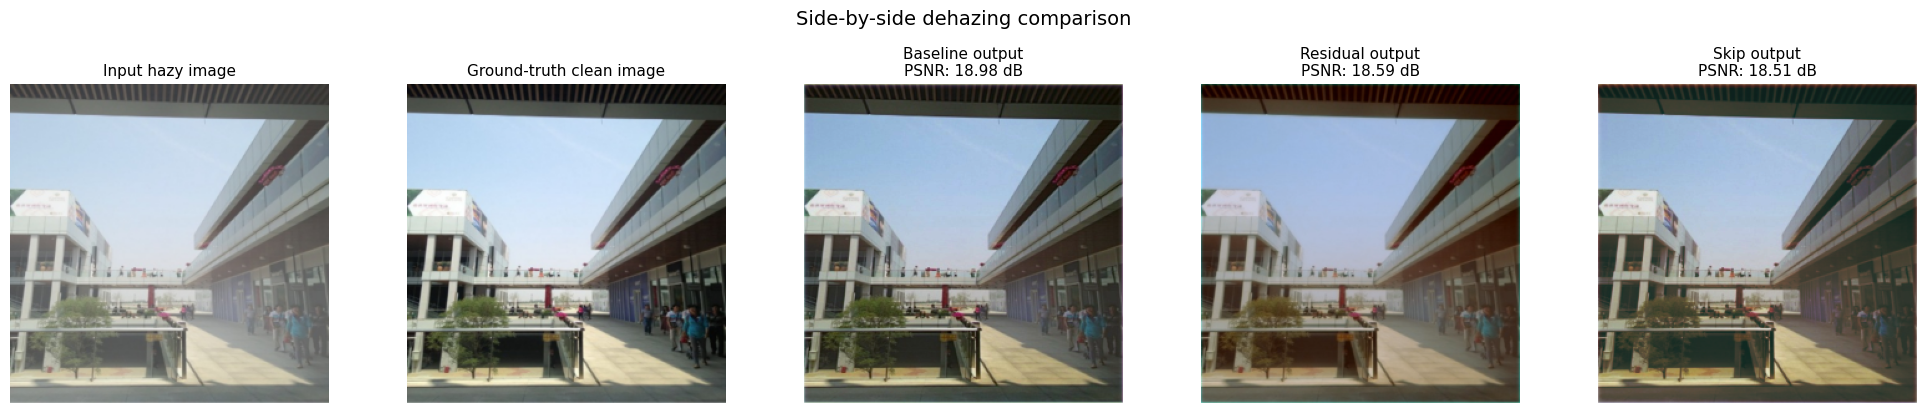

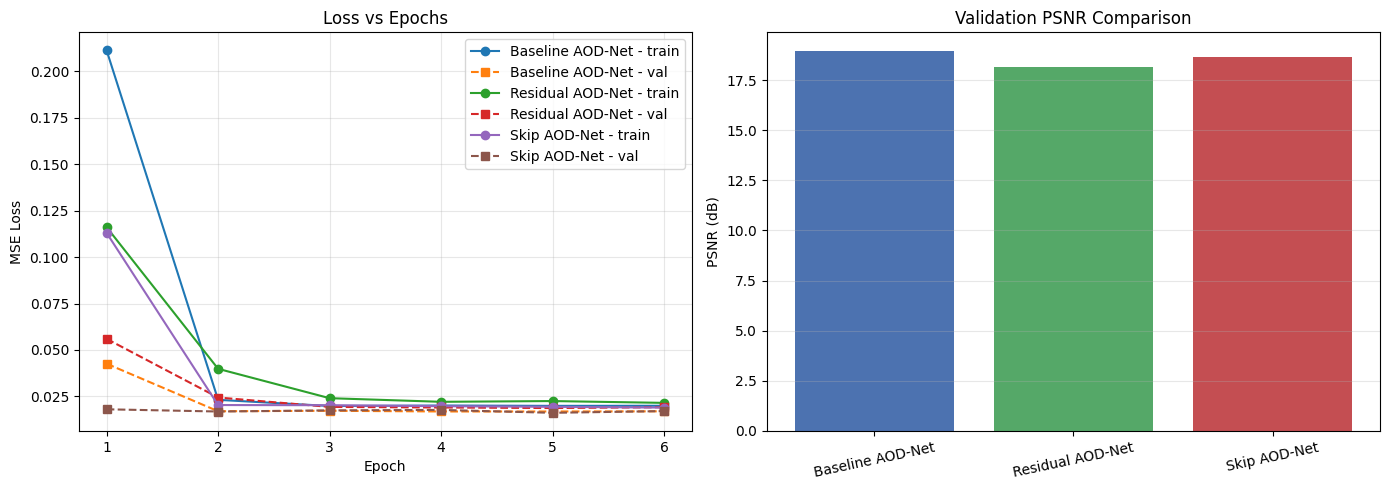

In [9]:
# Summarize the trained models and create the presentation figures.
def summarize_final_metrics(histories_dict):
    """Print the final validation loss and PSNR for each trained model."""
    print('Final validation metrics:')
    for model_name, history in histories_dict.items():
        print(f"- {model_name}: loss={history['val_loss'][-1]:.6f}, PSNR={history['val_psnr'][-1]:.2f} dB")

def get_single_validation_example(dataset, index=0):
    """Fetch one `(clean, hazy)` pair from the validation set for side-by-side comparison."""
    clean_image, hazy_image = dataset[index]
    return clean_image.unsqueeze(0).to(device), hazy_image.unsqueeze(0).to(device)

summarize_final_metrics(histories)

# Pick one validation example so all three model outputs are compared on the same input.
clean_batch, hazy_batch = get_single_validation_example(val_dataset, index=0)
model_outputs = {}

with torch.no_grad():
    for model_name, model in models.items():
        model.eval()
        model_outputs[model_name] = model(hazy_batch).cpu().squeeze(0)

clean_image = clean_batch.cpu().squeeze(0)
hazy_image = hazy_batch.cpu().squeeze(0)

baseline_psnr = compute_psnr(model_outputs['Baseline AOD-Net'].unsqueeze(0), clean_batch.cpu())
residual_psnr = compute_psnr(model_outputs['Residual AOD-Net'].unsqueeze(0), clean_batch.cpu())
skip_psnr = compute_psnr(model_outputs['Skip AOD-Net'].unsqueeze(0), clean_batch.cpu())

comparison_images = [
    hazy_image,
    clean_image,
    model_outputs['Baseline AOD-Net'],
    model_outputs['Residual AOD-Net'],
    model_outputs['Skip AOD-Net'],
]

comparison_titles = [
    'Input hazy image',
    'Ground-truth clean image',
    f'Baseline output\nPSNR: {baseline_psnr:.2f} dB',
    f'Residual output\nPSNR: {residual_psnr:.2f} dB',
    f'Skip output\nPSNR: {skip_psnr:.2f} dB',
]

show_image_grid(
    comparison_images,
    titles=comparison_titles,
    figsize=(20, 4),
    suptitle='Side-by-side dehazing comparison',
)

# Plot loss curves and PSNR values for the three model variants.
epochs_axis = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model_name, history in histories.items():
    # Plot both train and validation curves so underfitting or overfitting is visible.
    plt.plot(epochs_axis, history['train_loss'], marker='o', label=f'{model_name} - train')
    plt.plot(epochs_axis, history['val_loss'], marker='s', linestyle='--', label=f'{model_name} - val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss vs Epochs')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
# Compare the final PSNR of the three trained models with a simple bar chart.
final_psnr = [history['val_psnr'][-1] for history in histories.values()]
plt.bar(list(histories.keys()), final_psnr, color=['#4c72b0', '#55a868', '#c44e52'])
plt.ylabel('PSNR (dB)')
plt.title('Validation PSNR Comparison')
plt.xticks(rotation=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Demo-Style Inference

The original `demo.py` loads a pretrained network, preprocesses images, runs inference, and saves the output. The next cell provides the same idea in notebook form.

If you place a hazy image inside `data/clean_images`, the cell will run a simple single-image demo using the trained skip-connection model.


In [10]:
# A demo-style inference helper inspired by demo.py from the original repository.
def dehaze_image_from_path(model, image_path, image_size=IMAGE_SIZE):
    """Load one image from disk, resize it, run dehazing, and return both tensors."""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    hazy_tensor = resize_to_tensor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        dehazed_tensor = model(hazy_tensor).cpu().squeeze(0)

    return hazy_tensor.cpu().squeeze(0), dehazed_tensor

# Search for any real images dropped into the project folder for an optional demo.
demo_candidates = []
for pattern in ('*.png', '*.jpg', '*.jpeg'):
    demo_candidates.extend(sorted(LOCAL_IMAGE_DIR.glob(pattern)))

if demo_candidates:
    demo_hazy, demo_dehazed = dehaze_image_from_path(models['Skip AOD-Net'], demo_candidates[0])
    show_image_grid(
        [demo_hazy, demo_dehazed],
        titles=['Demo input image', 'Skip-connection dehazing output'],
        suptitle=f'Demo inference on {demo_candidates[0].name}',
    )
else:
    print(f'Place a test image inside {LOCAL_IMAGE_DIR} to run the demo-style inference cell.')


Place a test image inside D:\JetAcker_RoadSim\NNDL_Project\data\clean_images to run the demo-style inference cell.


## Conclusion

This notebook shows the full academic story in one place:

- Baseline AOD-Net learns a direct hazy-to-clean mapping.
- Residual learning reframes the task as estimating the haze that should be removed.
- Skip connections help preserve low-level details by reusing the input image.
- Loss curves and PSNR make the comparison quantitative, while side-by-side figures make it easy to explain qualitatively.

For a stronger final project, you can replace the synthetic dataset with a real paired dehazing dataset and reuse exactly the same training, evaluation, and visualization pipeline.
